# Phase 2 - Dataset Loading and EDA

This notebook loads the leakage-safe RACE splits (`train`, `val`, `test`) from `data/splits` and computes core exploratory data analysis metrics before model training.

In [8]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

# Make project src importable when running from notebooks/
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import EXPECTED_COLUMNS, load_dataset_splits

In [9]:
DATA_DIR = PROJECT_ROOT / "data" / "splits"
REPORT_DIR = PROJECT_ROOT / "report"
FIGURES_DIR = PROJECT_ROOT / "figures"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

splits = load_dataset_splits(DATA_DIR)
combined_df = pd.concat(splits.values(), ignore_index=True)

print({name: len(df) for name, df in splits.items()})
print(f"Total rows across splits: {len(combined_df)}")

{'train': 70331, 'val': 8784, 'test': 8736}
Total rows across splits: 87851


In [10]:
def safe_text_len(value):
    if pd.isna(value):
        return 0
    return len(str(value).strip())


def compute_eda_summary(train_df, val_df, test_df):
    all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

    row_counts = {
        "train_rows": len(train_df),
        "val_rows": len(val_df),
        "test_rows": len(test_df),
        "total_rows": len(all_df),
    }

    missing_values = all_df[EXPECTED_COLUMNS].isna().sum().to_dict() if not all_df.empty else {col: 0 for col in EXPECTED_COLUMNS}

    answer_distribution = (
        all_df["answer"].value_counts().reindex(["A", "B", "C", "D"], fill_value=0).to_dict()
        if not all_df.empty
        else {"A": 0, "B": 0, "C": 0, "D": 0}
    )

    if all_df.empty:
        avg_article_len = 0.0
        avg_question_len = 0.0
        avg_option_len = 0.0
        longest_article_len = 0
        shortest_article_len = 0
        longest_article_id = ""
        shortest_article_id = ""
    else:
        article_lengths = all_df["article"].map(safe_text_len)
        question_lengths = all_df["question"].map(safe_text_len)
        option_lengths = all_df[["A", "B", "C", "D"]].applymap(safe_text_len)

        avg_article_len = float(article_lengths.mean())
        avg_question_len = float(question_lengths.mean())
        avg_option_len = float(option_lengths.stack().mean())

        longest_idx = article_lengths.idxmax()
        shortest_idx = article_lengths.idxmin()

        longest_article_len = int(article_lengths.loc[longest_idx])
        shortest_article_len = int(article_lengths.loc[shortest_idx])
        longest_article_id = str(all_df.loc[longest_idx, "id"])
        shortest_article_id = str(all_df.loc[shortest_idx, "id"])

    summary = {
        **row_counts,
        **{f"missing_{k}": int(v) for k, v in missing_values.items()},
        **{f"answer_count_{k}": int(v) for k, v in answer_distribution.items()},
        "avg_article_length": avg_article_len,
        "avg_question_length": avg_question_len,
        "avg_option_length": avg_option_len,
        "longest_article_length": longest_article_len,
        "shortest_article_length": shortest_article_len,
        "longest_article_id": longest_article_id,
        "shortest_article_id": shortest_article_id,
    }

    return all_df, summary

In [11]:
all_df, summary = compute_eda_summary(splits["train"], splits["val"], splits["test"])

summary_df = pd.DataFrame([summary])
summary_path = REPORT_DIR / "eda_summary.csv"
summary_df.to_csv(summary_path, index=False)

summary_df.T

,0
train_rows,70331
val_rows,8784
test_rows,8736
total_rows,87851
missing_id,0
missing_article,0
missing_question,0
missing_A,0
missing_B,0
missing_C,0


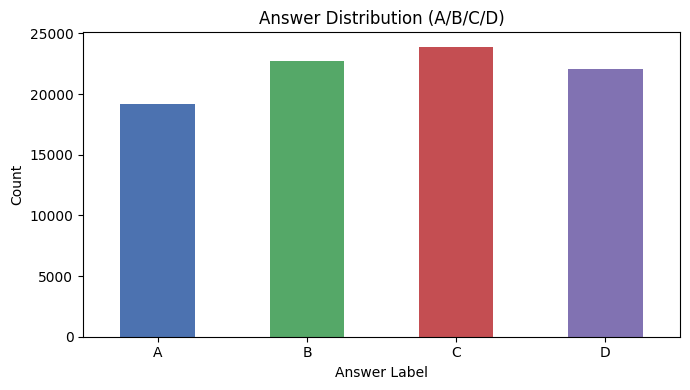

In [12]:
answer_counts = (
    all_df["answer"].value_counts().reindex(["A", "B", "C", "D"], fill_value=0)
    if not all_df.empty
    else pd.Series([0, 0, 0, 0], index=["A", "B", "C", "D"])
)

plt.figure(figsize=(7, 4))
answer_counts.plot(kind="bar", color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
plt.title("Answer Distribution (A/B/C/D)")
plt.xlabel("Answer Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "answer_distribution.png", dpi=200)
plt.show()

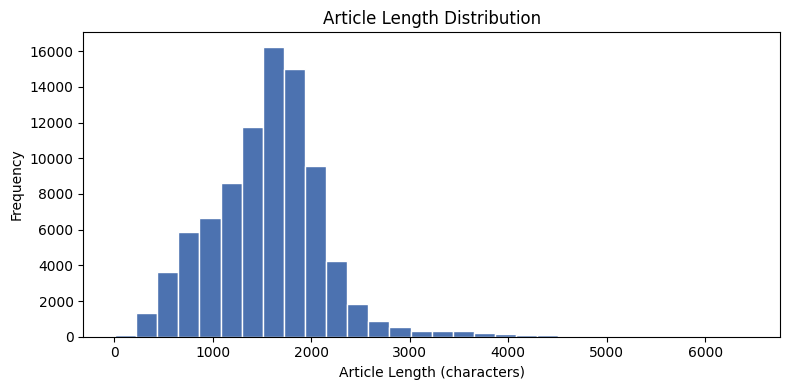

In [13]:
article_lengths = all_df["article"].map(safe_text_len) if not all_df.empty else pd.Series([0])

plt.figure(figsize=(8, 4))
plt.hist(article_lengths, bins=30, color="#4C72B0", edgecolor="white")
plt.title("Article Length Distribution")
plt.xlabel("Article Length (characters)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "article_length_distribution.png", dpi=200)
plt.show()

In [14]:
print("Sample rows from each split")
for split_name, df in splits.items():
    print(f"\n--- {split_name.upper()} ---")
    if df.empty:
        print("No rows available.")
    else:
        display(df.head(3))

print(f"\nSaved summary to: {summary_path}")
print(f"Saved figures to: {FIGURES_DIR}")

Sample rows from each split

--- TRAIN ---


,id,article,question,A,B,C,D,answer
0,middle7348.txt,In the summer between my first year and second...,Before the writer came to the high school summ...,instructor,camper,student,reporter,C
1,middle7348.txt,In the summer between my first year and second...,How many times did the writer invite the boy t...,Once,Twice,Three times,Many times,B
2,middle4305.txt,A bumpkin went to a big city for the first t...,The bumpkin thought _ .,his wife was as beautiful as the young girl,his wife was more beautiful than the short fat...,the short fat woman changed to a young girl in...,He should also buy a room of that kind for his...,C



--- VAL ---


,id,article,question,A,B,C,D,answer
0,middle4241.txt,"""Green"" is more than just a color. It also mea...",We can _ the paper and cans to being green.,recycle,reuse,reduce,throw away,A
1,middle4241.txt,"""Green"" is more than just a color. It also mea...",_ not only can save energy but also can do s...,Walking to work,Turn off your phone,Recycling bottles,Brushing your teeth,A
2,middle4241.txt,"""Green"" is more than just a color. It also mea...","According to this passage, the ""green"" means _",a kind of color,protect the environment,the plants and the land,the air we breathe,B



--- TEST ---


,id,article,question,A,B,C,D,answer
0,middle7644.txt,"Dear Mary,\nI'm sorry to hear that you didn't ...",What's the matter with Mary?,She has no time to study math.,She doesn't want to learn math.,She can't find a right way to learn math well.,She can't get good grades in the exam.,C
1,middle7644.txt,"Dear Mary,\nI'm sorry to hear that you didn't ...","The underline sentence ""The only difficult que...",There is no difficult question in learning math.,There is no difficult question if you can ask ...,There is only one difficult question in learni...,There is only one difficult question if you as...,B
2,middle7644.txt,"Dear Mary,\nI'm sorry to hear that you didn't ...",Which is the wrong way to learn math well?,"If you don't understand a step, you could ask ...",You should do your homework every day carefully.,You should review all of your notes in your no...,You should copy other students' homework.,D



Saved summary to: C:\Users\rayaan\Desktop\AI_Proj\race_rc_project\report\eda_summary.csv
Saved figures to: C:\Users\rayaan\Desktop\AI_Proj\race_rc_project\figures
